# **COVID-19 CHEST X-RAY CLASSIFICATION USING DEEP LEARNING**

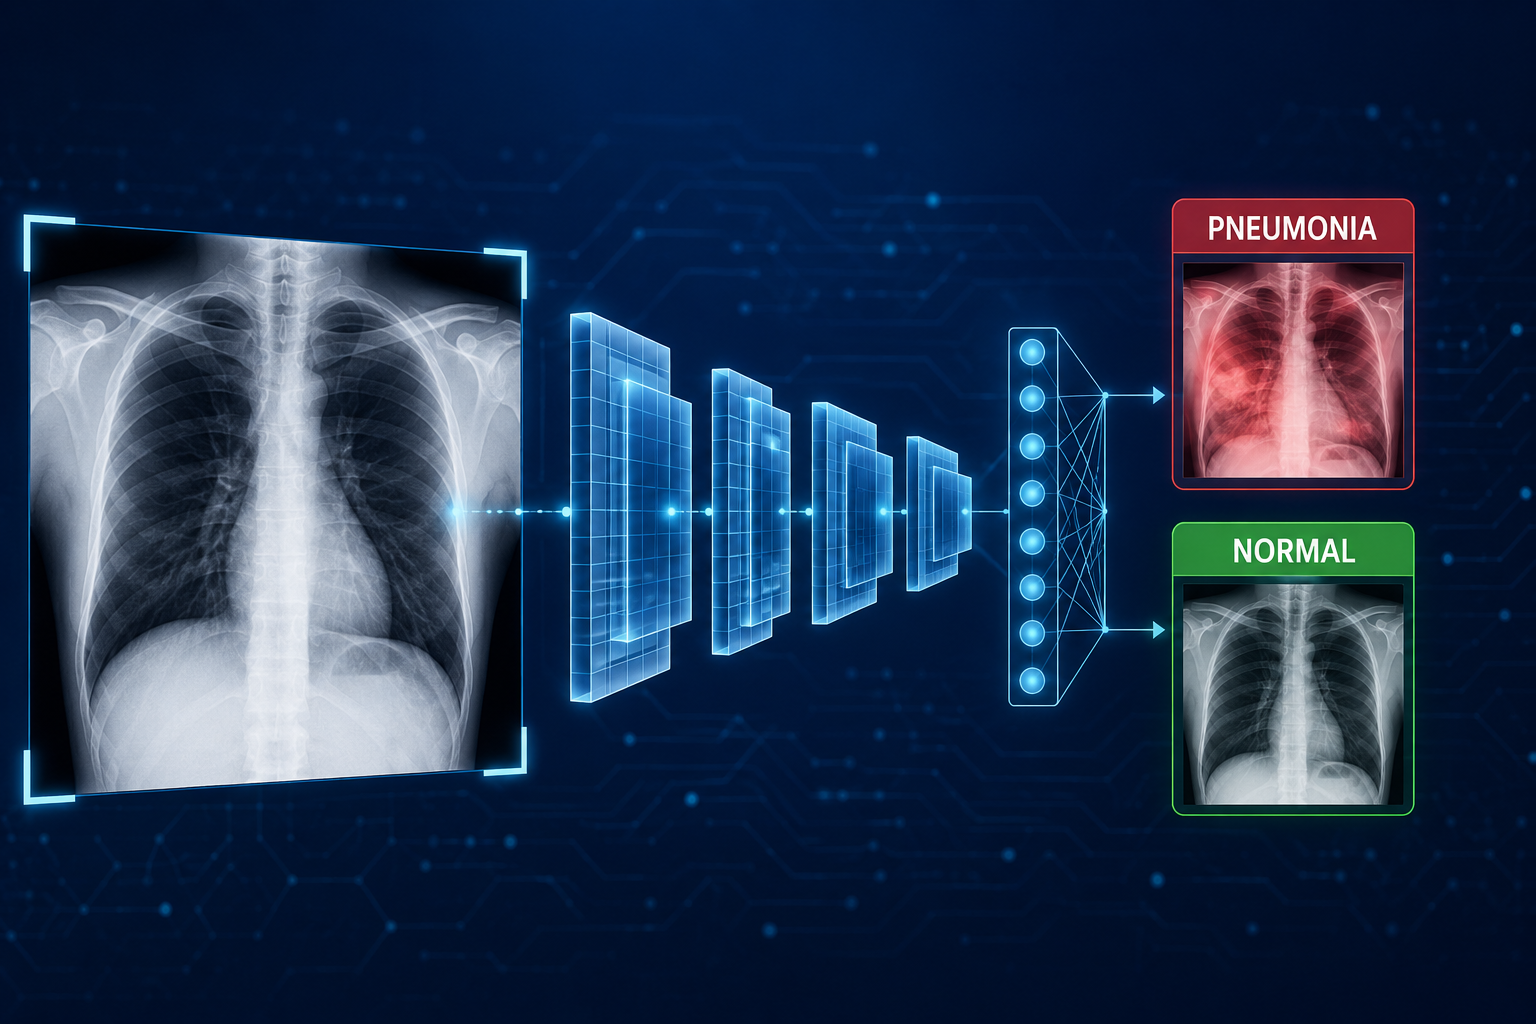

# **INTRODUCTION**

COVID-19 is a respiratory disease that can cause abnormalities in the lungs. Chest X-ray images can contain visible patterns associated with respiratory infections and pneumonia. With the development of deep learning, Convolutional Neural Networks (CNNs) can be used to automatically analyze medical images and classify them into different categories.

This project presents a deep learning-based image classification system using a Convolutional Neural Network (CNN). The system processes chest X-ray images and classifies them into two categories: PNEUMONIA and NORMAL. The images are resized to a fixed size of 150 × 150 pixels before being provided to the CNN model.

Dataset : https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets?select=xray_dataset_covid19

**OBJECTIVE**

The main objectives of this project are:

1. To develop a deep learning model for chest X-ray image classification.
2. To preprocess and resize X-ray images into a suitable format for CNN processing.
3. To train a CNN model using labeled X-ray images.
4. To evaluate the performance of the trained model using test images.
5. To predict the class of a new chest X-ray image.
6. To measure model performance using accuracy, precision, recall and F1-score.

**DATA LOADING**

In [1]:
from skimage.io import imread
from skimage.transform import resize
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPool2D,Flatten

In [2]:
import os

In [3]:
os.listdir('/content/drive/MyDrive/xray_dataset_covid19/train')

['PNEUMONIA', 'NORMAL']

In [4]:
os.listdir('/content/drive/MyDrive/xray_dataset_covid19/train')

['PNEUMONIA', 'NORMAL']

In [5]:
datadir='/content/drive/MyDrive/xray_dataset_covid19/train'
x_train=[]
y_train=[]
categories=['PNEUMONIA', 'NORMAL']
for i in categories:
  print('loading',i)
  sub_path=os.path.join(datadir,i)
  #print(sub_path)
  images=os.listdir(sub_path)
  #print(images)
  for img in images:
    img_path=os.path.join(sub_path,img)
    #print(img_path)
    img_array=imread(img_path)
    img_resize=resize(img_array,(150,150,1))
    x_train.append(img_resize)
    y_train.append(categories.index(i))
  print('loaded',i)

loading PNEUMONIA
loaded PNEUMONIA
loading NORMAL
loaded NORMAL


In [6]:
datadir1='/content/drive/MyDrive/xray_dataset_covid19/train'
x_test=[]
y_test=[]
categories=['PNEUMONIA', 'NORMAL']
for i in categories:
  print('loading',i)
  sub_path=os.path.join(datadir1,i)
  images=os.listdir(sub_path)
  for img in images:
    img_path=os.path.join(sub_path,img)
    img_array=imread(img_path)
    img_resize=resize(img_array,(150,150,1))
    x_test.append(img_resize)
    y_test.append(categories.index(i))
  print('loaded',i)

loading PNEUMONIA
loaded PNEUMONIA
loading NORMAL
loaded NORMAL


**DATA PREPROCESSING**

In [7]:
import numpy as np
x_train=np.array(x_train)
x_test=np.array(x_test)
y_train=np.array(y_train)
y_test=np.array(y_test)
x_train.shape

(148, 150, 150, 1)

In [8]:
img_resize.shape

(150, 150, 1)

**CNN MODEL CREATION**

In [25]:
cnn=Sequential()
cnn.add(Conv2D(32,(3,3),input_shape=(150,150,1),activation='relu'))
cnn.add(MaxPool2D(2,2))
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPool2D(2,2))
cnn.add(Flatten())
cnn.add(Dense(100,activation='relu'))
cnn.add(Dense(2,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**MODEL COMPILATION**

In [26]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

**MODEL TRAINING**

In [27]:
cnn.fit(x_train,y_train,epochs=10,batch_size=20)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - accuracy: 0.5405 - loss: 1.3958
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.7703 - loss: 0.5131
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.8851 - loss: 0.3112
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.9324 - loss: 0.2044
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.9595 - loss: 0.1291
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.9662 - loss: 0.1235
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.9797 - loss: 0.0723
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.9730 - loss: 0.0933
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.9932 - loss: 0.0590
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - accuracy: 0.9932 - loss: 0.0440


**MODEL PREDICTION ON A NEW IMAGE**

In [28]:
img=imread('/content/drive/MyDrive/xray_dataset_covid19/test/NORMAL/NORMAL2-IM-0073-0001.jpeg')
img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [29]:
img=resize(img,(150,150,1))
img.shape

(150, 150, 1)

In [30]:
img=img.reshape(1,150,150,1)
img.shape

(1, 150, 150, 1)

In [31]:
y_new=cnn.predict(img)
y_new

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[0.19151375, 0.8084862 ]], dtype=float32)

In [32]:
ind=y_new.argmax()
ind

np.int64(1)

In [33]:
prediction=categories[ind]
prediction

'NORMAL'

**MODEL EVALUATION**

In [34]:
cnn.evaluate(x_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9797 - loss: 0.0476


[0.047649942338466644, 0.9797297120094299]

In [35]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [36]:
y_pred=cnn.predict(x_test)
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step


array([[9.99744773e-01, 2.55179359e-04],
       [9.95989442e-01, 4.01046034e-03],
       [9.99674499e-01, 3.25397035e-04],
       [9.99978602e-01, 2.12997456e-05],
       [9.99432445e-01, 5.67541749e-04],
       [9.99991238e-01, 8.73369299e-06],
       [9.99965131e-01, 3.48506364e-05],
       [9.99968231e-01, 3.16517508e-05],
       [9.95130599e-01, 4.86939726e-03],
       [9.85798001e-01, 1.42019363e-02],
       [9.99984682e-01, 1.52230323e-05],
       [9.97827590e-01, 2.17244378e-03],
       [9.49964523e-01, 5.00354618e-02],
       [9.99901474e-01, 9.84159051e-05],
       [9.99944866e-01, 5.50285222e-05],
       [9.99552488e-01, 4.47531056e-04],
       [9.97067809e-01, 2.93211476e-03],
       [9.98389781e-01, 1.61016267e-03],
       [9.99879301e-01, 1.20619610e-04],
       [9.98291492e-01, 1.70862302e-03],
       [9.98234034e-01, 1.76589889e-03],
       [9.99905288e-01, 9.46209184e-05],
       [9.99991357e-01, 8.56351198e-06],
       [9.99919713e-01, 8.01656279e-05],
       [9.931517

In [38]:
y_pred1=y_pred.argmax(axis=1)
y_pred1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

**CONFUSION MATRIX**

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        74
           1       1.00      0.96      0.98        74

    accuracy                           0.98       148
   macro avg       0.98      0.98      0.98       148
weighted avg       0.98      0.98      0.98       148



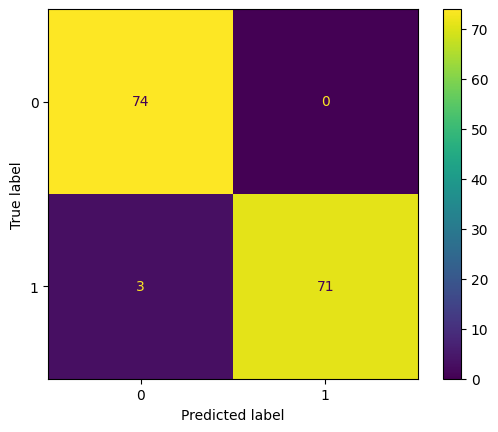

In [39]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test,y_pred1))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred1))

**CONCLUSION**

* This project demonstrates the use of a **Convolutional Neural Network** for automated classification of chest X-ray images. The system preprocesses X-ray images by resizing them to **150 × 150 × 1** and uses convolutional and pooling layers to extract image features.

* The trained CNN achieved approximately **97.97%** test accuracy on the dataset. The results demonstrate that CNN-based image classification can be effective for distinguishing between the **PNEUMONIA** and **NORMAL** categories in this dataset.

Overall, the project provides a practical demonstration of applying deep learning and computer vision techniques to medical image classification.